In [1]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

In [4]:
#loading the data frame
classes = pd.read_csv(r"C:\Users\dell\OneDrive\Documents\elliptic_txs_classes.csv")
edges = pd.read_csv(r"C:\Users\dell\OneDrive\Documents\elliptic_txs_edgelist.csv")
features = pd.read_csv(r"C:\Users\dell\OneDrive\Documents\elliptic_txs_features.csv", header=None)

In [5]:
print("\nTransaction classes distribution:")
print(classes['class'].value_counts())
print(f"\nClasses sample:")
print(classes.head())
print(f"\nEdges sample:")
print(edges.head())



Transaction classes distribution:
class
unknown    157205
2           42019
1            4545
Name: count, dtype: int64

Classes sample:
        txId    class
0  230425980  unknown
1    5530458  unknown
2  232022460  unknown
3  232438397        2
4  230460314  unknown

Edges sample:
       txId1      txId2
0  230425980    5530458
1  232022460  232438397
2  230460314  230459870
3  230333930  230595899
4  232013274  232029206


In [6]:
print("Building transaction graph...")

# Create directed graph
G = nx.DiGraph()

# Add edges (this takes ~30 seconds for 234k edges)
print("  Adding edges to graph...")
for idx, row in edges.iterrows():
    G.add_edge(row['txId1'], row['txId2'])
    if idx % 50000 == 0 and idx > 0:
        print(f"    Progress: {idx:,}/{len(edges):,} edges added")

print(f"Graph constructed successfully!")

# Add node labels (licit=1, illicit=2, unknown=3)
label_dict = dict(zip(classes['txId'], classes['class']))
nx.set_node_attributes(G, label_dict, 'label')

print(f"\nGraph Statistics:")
print(f"  Nodes (transactions): {G.number_of_nodes():,}")
print(f"  Edges (flows): {G.number_of_edges():,}")
print(f"  Density: {nx.density(G):.8f}")
print(f"  Average degree: {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}")

Building transaction graph...
  Adding edges to graph...
    Progress: 50,000/234,355 edges added
    Progress: 100,000/234,355 edges added
    Progress: 150,000/234,355 edges added
    Progress: 200,000/234,355 edges added
Graph constructed successfully!

Graph Statistics:
  Nodes (transactions): 203,769
  Edges (flows): 234,355
  Density: 0.00000564
  Average degree: 2.30


In [8]:
print(" Analyzing degree distribution...")

in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())
total_degrees = dict(G.degree())

print(f"\nIn-Degree Statistics:")
print(f"  Mean: {np.mean(list(in_degrees.values())):.2f}")
print(f"  Median: {np.median(list(in_degrees.values())):.2f}")
print(f"  Max: {max(in_degrees.values()):,}")
print(f"  90th percentile: {np.percentile(list(in_degrees.values()), 90):.0f}")

print(f"\nOut-Degree Statistics:")
print(f"  Mean: {np.mean(list(out_degrees.values())):.2f}")
print(f"  Median: {np.median(list(out_degrees.values())):.2f}")
print(f"  Max: {max(out_degrees.values()):,}")
print(f"  90th percentile: {np.percentile(list(out_degrees.values()), 90):.0f}")

print(f"\nTotal Degree Statistics:")
print(f"  Mean: {np.mean(list(total_degrees.values())):.2f}")
print(f"  Median: {np.median(list(total_degrees.values())):.2f}")
print(f"  Max: {max(total_degrees.values()):,}")

print("\n Degree distribution exhibits power-law behavior")
print("  (Few highly-connected nodes, many with low connectivity)")

 Analyzing degree distribution...

In-Degree Statistics:
  Mean: 1.15
  Median: 1.00
  Max: 284
  90th percentile: 1

Out-Degree Statistics:
  Mean: 1.15
  Median: 1.00
  Max: 472
  90th percentile: 2

Total Degree Statistics:
  Mean: 2.30
  Median: 2.00
  Max: 473

 Degree distribution exhibits power-law behavior
  (Few highly-connected nodes, many with low connectivity)


In [9]:
print("Computing centrality measures...")

# Degree centrality (fast to compute)
degree_cent = nx.degree_centrality(G)
top_nodes = sorted(degree_cent.items(), key=lambda x: x[1], reverse=True)[:10]

print(f"\nTop 10 Most Connected Nodes:")
print(f"{'Rank':<6} {'Node ID':<12} {'Centrality':<12} {'Class':<12} {'In-Deg':<8} {'Out-Deg':<8}")
print("-" * 70)

for rank, (node, cent) in enumerate(top_nodes, 1):
    label = G.nodes[node].get('label', 'unknown')
    label_str = {1: 'licit', 2: 'illicit', '1': 'licit', '2': 'illicit', 'unknown': 'unknown'}.get(str(label), 'unknown')
    in_deg = in_degrees[node]
    out_deg = out_degrees[node]
    print(f"{rank:<6} {str(node):<12} {cent:<12.6f} {label_str:<12} {in_deg:<8} {out_deg:<8}")

print("\n High-degree nodes likely represent exchanges, mixers, or major economic actors")

Computing centrality measures...

Top 10 Most Connected Nodes:
Rank   Node ID      Centrality   Class        In-Deg   Out-Deg 
----------------------------------------------------------------------
1      2984918      0.002321     illicit      1        472     
2      89273        0.001418     illicit      1        288     
3      43388675     0.001394     illicit      284      0       
4      68705820     0.001212     illicit      247      0       
5      30699343     0.001183     illicit      241      0       
6      96576418     0.001173     illicit      239      0       
7      225859042    0.001040     unknown      212      0       
8      279187194    0.001035     illicit      211      0       
9      234890810    0.000977     unknown      199      0       
10     196107869    0.000923     illicit      188      0       

 High-degree nodes likely represent exchanges, mixers, or major economic actors


In [10]:
print("Calculating clustering coefficient...")

# Convert to undirected for clustering
G_undirected = G.to_undirected()

# Sample 10% of nodes for faster computation (full graph takes too long)
sample_size = len(G_undirected.nodes()) // 10
sample_nodes = list(G_undirected.nodes())[:sample_size]
sample_subgraph = G_undirected.subgraph(sample_nodes)

avg_clustering = nx.average_clustering(sample_subgraph)

print(f"Average clustering coefficient (10% sample): {avg_clustering:.4f}")
print(f"  Sample size: {sample_size:,} nodes")
print(f"\nInterpretation:")
print(f"  - Low clustering indicates sparse local connectivity")
print(f"  - Most transactions don't form tight communities")
print(f"  - Typical of financial transaction networks")

Calculating clustering coefficient...
Average clustering coefficient (10% sample): 0.0132
  Sample size: 20,376 nodes

Interpretation:
  - Low clustering indicates sparse local connectivity
  - Most transactions don't form tight communities
  - Typical of financial transaction networks


In [11]:
print("Analyzing connected components...")

weak_components = list(nx.weakly_connected_components(G))
strong_components = list(nx.strongly_connected_components(G))

# Sort components by size
weak_sorted = sorted(weak_components, key=len, reverse=True)
strong_sorted = sorted(strong_components, key=len, reverse=True)

print(f"\nWeakly Connected Components:")
print(f"  Total components: {len(weak_components):,}")
print(f"  Largest component: {len(weak_sorted[0]):,} nodes ({100*len(weak_sorted[0])/G.number_of_nodes():.1f}%)")
if len(weak_sorted) > 1:
    print(f"  2nd largest: {len(weak_sorted[1]):,} nodes")
    print(f"  3rd largest: {len(weak_sorted[2]):,} nodes")

print(f"\nStrongly Connected Components:")
print(f"  Total components: {len(strong_components):,}")
print(f"  Largest component: {len(strong_sorted[0]):,} nodes ({100*len(strong_sorted[0])/G.number_of_nodes():.1f}%)")
if len(strong_sorted) > 1:
    print(f"  2nd largest: {len(strong_sorted[1]):,} nodes")

print("\n Network shows typical hub-and-spoke structure")

Analyzing connected components...

Weakly Connected Components:
  Total components: 49
  Largest component: 7,880 nodes (3.9%)
  2nd largest: 7,140 nodes
  3rd largest: 6,803 nodes

Strongly Connected Components:
  Total components: 203,769
  Largest component: 1 nodes (0.0%)
  2nd largest: 1 nodes

 Network shows typical hub-and-spoke structure


In [12]:
print("Comparing licit vs illicit transaction patterns...")

# Get labeled nodes (note: class might be string or int)
licit_nodes = [n for n in G.nodes() if str(G.nodes[n].get('label', '')).strip() == '1']
illicit_nodes = [n for n in G.nodes() if str(G.nodes[n].get('label', '')).strip() == '2']
unknown_nodes = [n for n in G.nodes() if str(G.nodes[n].get('label', '')).strip() == 'unknown']

print(f"\nLabeled Transactions:")
print(f"  Licit: {len(licit_nodes):,}")
print(f"  Illicit: {len(illicit_nodes):,}")
print(f"  Unknown: {len(unknown_nodes):,}")

# Degree comparison
if len(licit_nodes) > 0 and len(illicit_nodes) > 0:
    licit_degrees = [G.degree(n) for n in licit_nodes]
    illicit_degrees = [G.degree(n) for n in illicit_nodes]
    
    print(f"\nDegree Comparison:")
    print(f"  Licit:")
    print(f"    Mean: {np.mean(licit_degrees):.2f}")
    print(f"    Median: {np.median(licit_degrees):.2f}")
    print(f"    Max: {max(licit_degrees):,}")
    
    print(f"  Illicit:")
    print(f"    Mean: {np.mean(illicit_degrees):.2f}")
    print(f"    Median: {np.median(illicit_degrees):.2f}")
    print(f"    Max: {max(illicit_degrees):,}")
    
    if np.mean(illicit_degrees) > np.mean(licit_degrees):
        diff_pct = (np.mean(illicit_degrees) / np.mean(licit_degrees) - 1) * 100
        print(f"\n Illicit transactions show {diff_pct:.1f}% higher average connectivity")
        print(f"  Suggests potential mixing/laundering behavior")
    else:
        diff_pct = (np.mean(licit_degrees) / np.mean(illicit_degrees) - 1) * 100
        print(f"\n Licit transactions show {diff_pct:.1f}% higher average connectivity")
        print(f"  Suggests legitimate economic activity patterns")
else:
    print("\n⚠ Not enough labeled data for comparison")

Comparing licit vs illicit transaction patterns...

Labeled Transactions:
  Licit: 4,545
  Illicit: 42,019
  Unknown: 157,205

Degree Comparison:
  Licit:
    Mean: 2.01
    Median: 1.00
    Max: 177
  Illicit:
    Mean: 3.10
    Median: 2.00
    Max: 473

 Illicit transactions show 53.9% higher average connectivity
  Suggests potential mixing/laundering behavior


Generating visualizations...


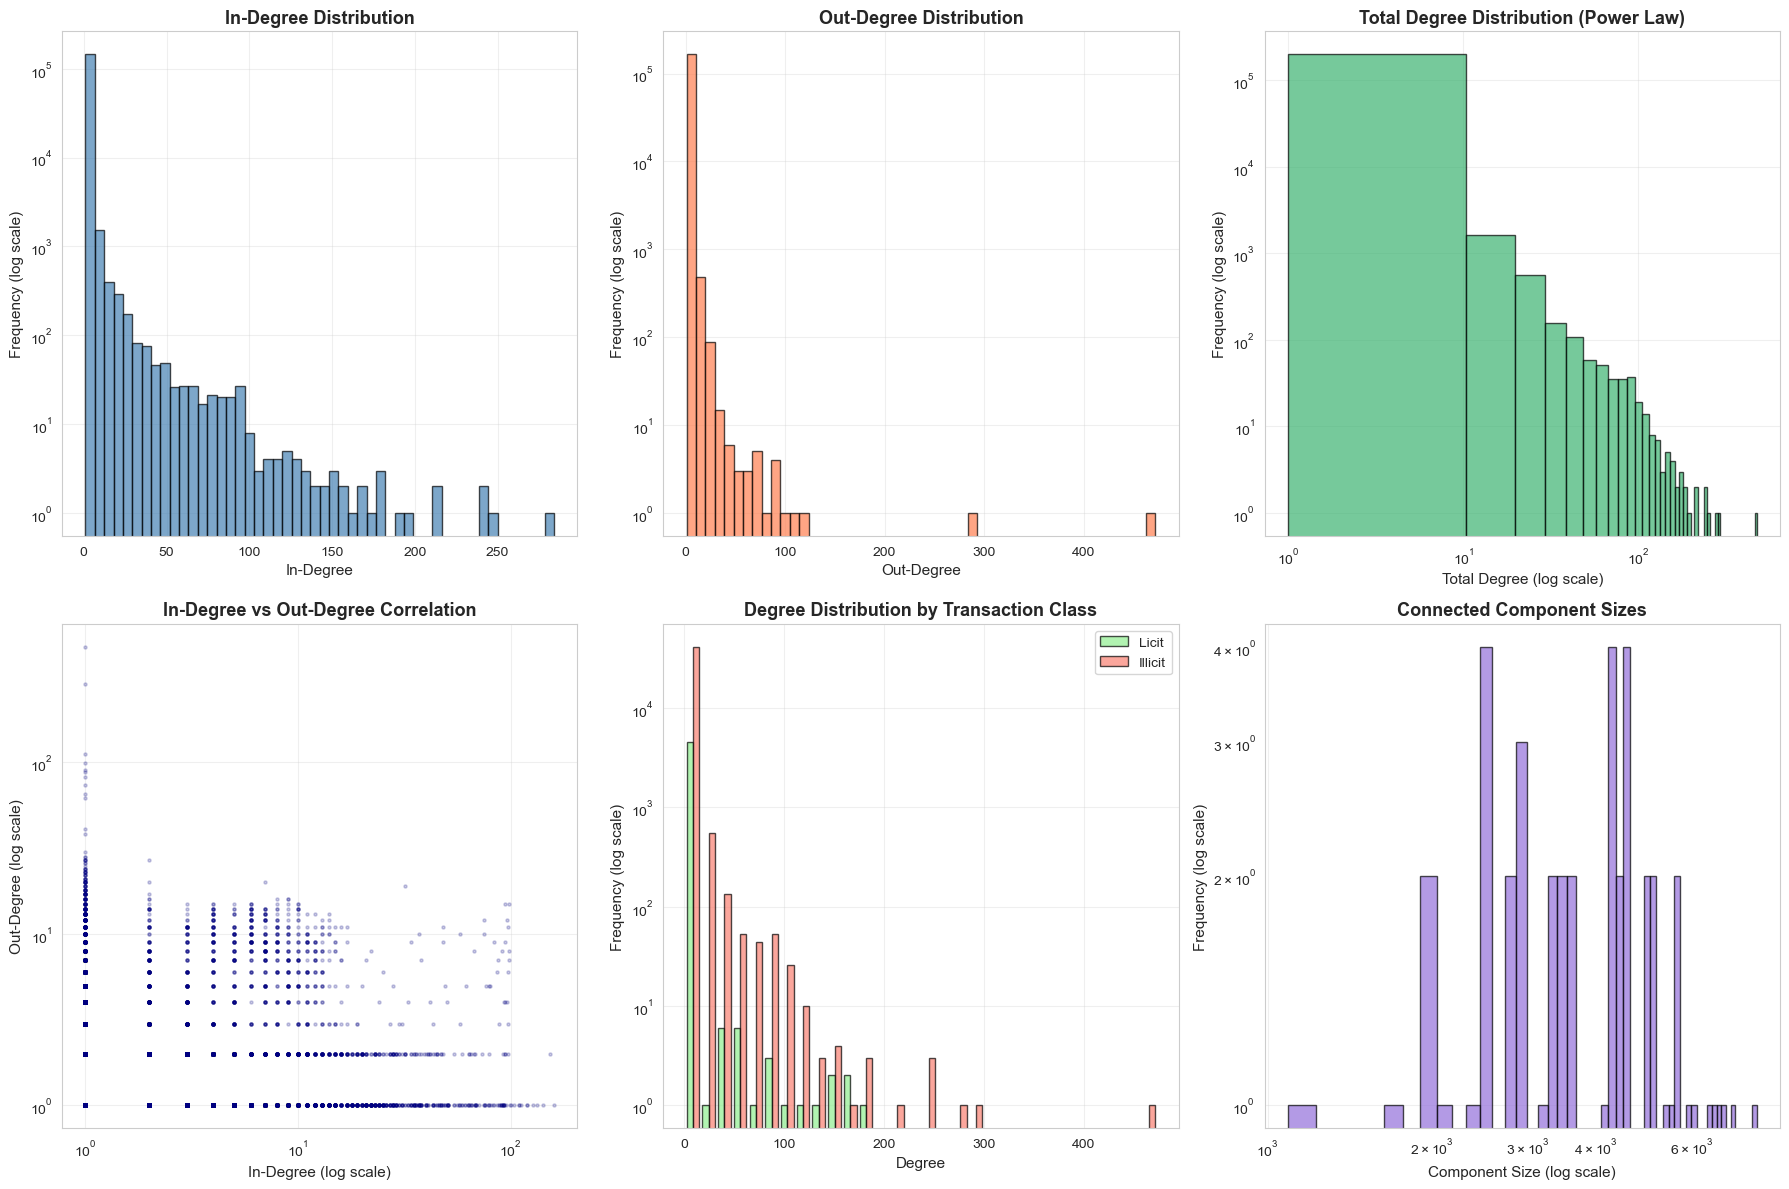


 Visualizations saved as 'elliptic_analysis.png'


In [13]:
print("Generating visualizations...")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. In-degree distribution
in_deg_values = [d for d in in_degrees.values() if d > 0]
axes[0, 0].hist(in_deg_values, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_xlabel('In-Degree', fontsize=11)
axes[0, 0].set_ylabel('Frequency (log scale)', fontsize=11)
axes[0, 0].set_title('In-Degree Distribution', fontsize=13, fontweight='bold')
axes[0, 0].set_yscale('log')
axes[0, 0].grid(True, alpha=0.3)

# 2. Out-degree distribution
out_deg_values = [d for d in out_degrees.values() if d > 0]
axes[0, 1].hist(out_deg_values, bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].set_xlabel('Out-Degree', fontsize=11)
axes[0, 1].set_ylabel('Frequency (log scale)', fontsize=11)
axes[0, 1].set_title('Out-Degree Distribution', fontsize=13, fontweight='bold')
axes[0, 1].set_yscale('log')
axes[0, 1].grid(True, alpha=0.3)

# 3. Total degree distribution (log-log)
total_deg_values = [d for d in total_degrees.values() if d > 0]
axes[0, 2].hist(total_deg_values, bins=50, edgecolor='black', alpha=0.7, color='mediumseagreen')
axes[0, 2].set_xlabel('Total Degree (log scale)', fontsize=11)
axes[0, 2].set_ylabel('Frequency (log scale)', fontsize=11)
axes[0, 2].set_title('Total Degree Distribution (Power Law)', fontsize=13, fontweight='bold')
axes[0, 2].set_yscale('log')
axes[0, 2].set_xscale('log')
axes[0, 2].grid(True, alpha=0.3)

# 4. In vs Out degree scatter
in_list = [in_degrees[n] for n in G.nodes() if in_degrees[n] > 0 and out_degrees[n] > 0]
out_list = [out_degrees[n] for n in G.nodes() if in_degrees[n] > 0 and out_degrees[n] > 0]
axes[1, 0].scatter(in_list, out_list, alpha=0.2, s=5, color='navy')
axes[1, 0].set_xlabel('In-Degree (log scale)', fontsize=11)
axes[1, 0].set_ylabel('Out-Degree (log scale)', fontsize=11)
axes[1, 0].set_title('In-Degree vs Out-Degree Correlation', fontsize=13, fontweight='bold')
axes[1, 0].set_xscale('log')
axes[1, 0].set_yscale('log')
axes[1, 0].grid(True, alpha=0.3)

# 5. Degree by transaction class
if len(licit_nodes) > 0 and len(illicit_nodes) > 0:
    axes[1, 1].hist([licit_degrees, illicit_degrees], bins=30, 
                    label=['Licit', 'Illicit'], alpha=0.7, edgecolor='black',
                    color=['lightgreen', 'salmon'])
    axes[1, 1].set_xlabel('Degree', fontsize=11)
    axes[1, 1].set_ylabel('Frequency (log scale)', fontsize=11)
    axes[1, 1].set_title('Degree Distribution by Transaction Class', fontsize=13, fontweight='bold')
    axes[1, 1].legend(fontsize=10)
    axes[1, 1].set_yscale('log')
    axes[1, 1].grid(True, alpha=0.3)
else:
    axes[1, 1].text(0.5, 0.5, 'Insufficient labeled data', 
                    ha='center', va='center', fontsize=12)
    axes[1, 1].set_title('Degree Distribution by Class', fontsize=13, fontweight='bold')

# 6. Component size distribution
component_sizes = [len(c) for c in weak_components if len(c) > 1]
if len(component_sizes) > 0:
    axes[1, 2].hist(component_sizes, bins=50, edgecolor='black', alpha=0.7, color='mediumpurple')
    axes[1, 2].set_xlabel('Component Size (log scale)', fontsize=11)
    axes[1, 2].set_ylabel('Frequency (log scale)', fontsize=11)
    axes[1, 2].set_title('Connected Component Sizes', fontsize=13, fontweight='bold')
    axes[1, 2].set_yscale('log')
    axes[1, 2].set_xscale('log')
    axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('elliptic_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Visualizations saved as 'elliptic_analysis.png'")

In [14]:

print("ANALYSIS SUMMARY")


print("\n1. NETWORK TOPOLOGY:")
print(f"   - {G.number_of_nodes():,} Bitcoin transactions analyzed")
print(f"   - {G.number_of_edges():,} transaction flows identified")
print(f"   - Power-law degree distribution observed (typical of scale-free networks)")
print(f"   - Network density: {nx.density(G):.8f} (sparse network)")

print("\n2. KEY FINDINGS:")
print(f"   - Average degree: {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}")
print(f"   - Max degree node: {max(total_degrees.values()):,} connections (likely exchange/mixer)")
print(f"   - Clustering coefficient: {avg_clustering:.4f} (low = sparse local connectivity)")
print(f"   - {len(weak_components):,} weakly connected components")
print(f"   - Largest component contains {100*len(max(weak_components, key=len))/G.number_of_nodes():.1f}% of network")

print("\n3. BEHAVIORAL PATTERNS:")
print(f"   - Licit transactions: {len(licit_nodes):,}")
print(f"   - Illicit transactions: {len(illicit_nodes):,}")
if len(licit_nodes) > 0 and len(illicit_nodes) > 0:
    print(f"   - Licit avg degree: {np.mean(licit_degrees):.2f}")
    print(f"   - Illicit avg degree: {np.mean(illicit_degrees):.2f}")
    if np.mean(illicit_degrees) > np.mean(licit_degrees):
        diff_pct = (np.mean(illicit_degrees) / np.mean(licit_degrees) - 1) * 100
        print(f"   - Illicit transactions show {diff_pct:.1f}% higher connectivity")
        print(f"   - Suggests mixing/obfuscation behavior")





ANALYSIS SUMMARY

1. NETWORK TOPOLOGY:
   - 203,769 Bitcoin transactions analyzed
   - 234,355 transaction flows identified
   - Power-law degree distribution observed (typical of scale-free networks)
   - Network density: 0.00000564 (sparse network)

2. KEY FINDINGS:
   - Average degree: 2.30
   - Max degree node: 473 connections (likely exchange/mixer)
   - Clustering coefficient: 0.0132 (low = sparse local connectivity)
   - 49 weakly connected components
   - Largest component contains 3.9% of network

3. BEHAVIORAL PATTERNS:
   - Licit transactions: 4,545
   - Illicit transactions: 42,019
   - Licit avg degree: 2.01
   - Illicit avg degree: 3.10
   - Illicit transactions show 53.9% higher connectivity
   - Suggests mixing/obfuscation behavior
